# seoul_airscore_v1_route_scoring

# 서울 러닝 추천용 AirScore v1

이 노트북은 2019~2025 서울 대기질 historical climatology를 실제 러닝 코스 점수로 변환한다.

---

## 최종 AirScore v1 공식

각 오염물질 농도를 2019~2025 서울 hourly 데이터의 **empirical percentile**로 변환한 뒤,
농도가 낮을수록 높은 점수가 되도록 뒤집는다.

```text
PollutantScore = 100 - Historical Percentile
```

그리고 다음 가중치로 결합한다.

| 오염물질 | 가중치 |
|---|---:|
| PM2.5 | 40% |
| O₃ | 25% |
| NO₂ | 15% |
| PM10 | 10% |
| CO | 5% |
| SO₂ | 5% |
| 합계 | 100% |

즉:

```text
AirScore
=
0.40 × PM2.5 Score
+ 0.25 × O3 Score
+ 0.15 × NO2 Score
+ 0.10 × PM10 Score
+ 0.05 × CO Score
+ 0.05 × SO2 Score
```

> 이 가중치는 특정 논문이나 WHO가 제시한 공식 위험점수가 아니다.  
> 서울 러닝 추천 프로젝트에서 사용할 **해석 가능한 heuristic AirScore v1**이다.

---

## PM10 24시간 값은 최종 AirScore에 넣지 않는다

`pm10_1h`과 `pm10_24h`를 동시에 넣으면 PM10 영향이 중복될 수 있으므로,
최종 AirScore에는 `pm10_1h`만 사용한다.

`pm10_24h`는 분석 및 검증용으로 보존한다.

---

## 서울 평균 대비 relative feature

`*_relative_median`은 최종 AirScore 가중합에 직접 넣지 않는다.

이유:

```text
해당 구의 historical concentration
```

자체가 이미 지역 차이를 반영하고 있기 때문이다.

relative feature는 다음 용도로 보존한다.

- 코스 설명
- 동점 코스 비교
- 이후 ML feature
- 서울 평균보다 상대적으로 좋은/나쁜 지역인지 해석

---

## Multi-gu route

여러 구를 지나는 코스는 구간별 AirScore를 계산한 뒤 **실제 러닝 소요시간**으로 가중평균한다.

예:

```text
3월 16:00 출발

강남구 4 km
송파구 6 km
```

페이스를 함께 입력하면 실제 예상 통과시간을 계산해서:

```text
district × month × hour
```

climatology를 구간별로 조회한다.

한 시간 경계를 넘으면 자동으로 구간을 나눈다.


## 1. 라이브러리

In [1]:
from pathlib import Path
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1-1. 한글 폰트 설정

In [2]:
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트:", plt.rcParams["font.family"])

한글 폰트: ['Malgun Gothic']


# 2. 경로 및 AirScore 설정

필요한 입력 파일은 두 개다.

```text
1) air_hourly_clean_2019_2026.csv
   → 2019~2025 empirical percentile 기준 생성용

2) historical_air_climatology_full_2019_2025.csv
   → district × month × hour historical context 조회용
```


In [3]:
PROJECT_DIR = Path(
    r"C:\Users\Luke\Desktop\DArtB\Toyproject"
)

RAW_DIR = PROJECT_DIR / "raw_air"
YEARLY_DIR = RAW_DIR / "yearly"

ANALYSIS_DIR = (
    PROJECT_DIR
    / "air_quality_analysis"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

HOURLY_PATH = (
    ANALYSIS_DIR
    / "air_hourly_clean_2019_2026.csv"
)

CLIMATOLOGY_PATH = (
    ANALYSIS_DIR
    / "feature_table"
    / "historical_air_climatology_full_2019_2025.csv"
)

OUTPUT_DIR = (
    ANALYSIS_DIR
    / "airscore_v1"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BASELINE_YEARS = list(
    range(2019, 2026)
)


# ============================================================
# AirScore v1 fixed weights
# ============================================================

AIR_WEIGHTS = {
    "pm25": 0.40,
    "o3": 0.25,
    "no2": 0.15,
    "pm10_1h": 0.10,
    "co": 0.05,
    "so2": 0.05
}


POLLUTANT_LABELS = {
    "pm25": "PM2.5",
    "o3": "O₃",
    "no2": "NO₂",
    "pm10_1h": "PM10",
    "co": "CO",
    "so2": "SO₂"
}


print("HOURLY_PATH:", HOURLY_PATH)
print("CLIMATOLOGY_PATH:", CLIMATOLOGY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

print("\nAirScore v1 weights:")

for pollutant, weight in AIR_WEIGHTS.items():

    print(
        f"- {POLLUTANT_LABELS[pollutant]}: "
        f"{weight:.0%}"
    )

print(
    "\n합계:",
    sum(AIR_WEIGHTS.values())
)

HOURLY_PATH: C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\air_hourly_clean_2019_2026.csv
CLIMATOLOGY_PATH: C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\feature_table\historical_air_climatology_full_2019_2025.csv
OUTPUT_DIR: C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\airscore_v1

AirScore v1 weights:
- PM2.5: 40%
- O₃: 25%
- NO₂: 15%
- PM10: 10%
- CO: 5%
- SO₂: 5%

합계: 1.0


# 3. 데이터 로드

In [4]:
ENCODINGS = [
    "utf-8-sig",
    "utf-8",
    "cp949",
    "euc-kr"
]


def read_csv_safe(path):
    last_error = None

    for enc in ENCODINGS:
        try:
            return pd.read_csv(
                path,
                encoding=enc,
                low_memory=False
            )
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"CSV 읽기 실패: {path}\n{last_error}"
    )


if not HOURLY_PATH.exists():
    raise FileNotFoundError(
        f"Hourly 파일이 없습니다:\n{HOURLY_PATH}"
    )

if not CLIMATOLOGY_PATH.exists():
    raise FileNotFoundError(
        f"Climatology 파일이 없습니다:\n{CLIMATOLOGY_PATH}"
    )


hourly = read_csv_safe(
    HOURLY_PATH
)

climatology = read_csv_safe(
    CLIMATOLOGY_PATH
)


hourly["datetime"] = pd.to_datetime(
    hourly["datetime"],
    errors="coerce"
)


print("hourly:", hourly.shape)
print("climatology:", climatology.shape)

display(
    climatology.head()
)

hourly: (1693432, 14)
climatology: (7200, 60)


,district_code,district,month,hour,pm10_1h_mean,pm10_1h_median,pm10_1h_p90,pm10_1h_observation_count,pm10_24h_mean,pm10_24h_median,pm10_24h_p90,pm10_24h_observation_count,pm25_mean,pm25_median,pm25_p90,pm25_observation_count,o3_mean,o3_median,o3_p90,o3_observation_count,no2_mean,no2_median,no2_p90,no2_observation_count,co_mean,co_median,co_p90,co_observation_count,so2_mean,so2_median,so2_p90,so2_observation_count,pm10_1h_relative_mean,pm10_1h_relative_median,pm10_1h_relative_p90,pm10_1h_relative_observation_count,pm10_24h_relative_mean,pm10_24h_relative_median,pm10_24h_relative_p90,pm10_24h_relative_observation_count,pm25_relative_mean,pm25_relative_median,pm25_relative_p90,pm25_relative_observation_count,o3_relative_mean,o3_relative_median,o3_relative_p90,o3_relative_observation_count,no2_relative_mean,no2_relative_median,no2_relative_p90,no2_relative_observation_count,co_relative_mean,co_relative_median,co_relative_p90,co_relative_observation_count,so2_relative_mean,so2_relative_median,so2_relative_p90,so2_relative_observation_count
0,0,강남구,1,0,40.6157,34.0000,69.5000,216,41.1198,37.0000,67.4000,217,26.5991,21.0000,47.2000,217,0.0142,0.0130,0.0290,217,0.0330,0.0330,0.0540,217,0.5972,0.5200,0.9000,217,0.0035,0.0030,0.0054,217,-2.2239,-1.9167,2.8211,216,-1.6697,-1.4000,1.6000,217,-0.0678,-0.0800,3.1920,217,0.0003,-0.0001,0.0042,217,-0.0008,-0.0010,0.0049,217,-0.0538,-0.0471,0.0368,217,0.0001,0.0000,0.0009,217
1,0,강남구,1,1,41.8796,34.0000,68.5000,216,40.7834,36.0000,65.8000,217,27.9493,22.0000,48.0000,217,0.0142,0.0120,0.0291,217,0.0319,0.0310,0.0530,217,0.5955,0.5500,0.9000,217,0.0035,0.0030,0.0060,217,-1.7884,-1.7350,3.7648,216,-1.6369,-1.2400,1.5360,217,0.4827,-0.0800,4.1200,217,0.0002,-0.0002,0.0041,217,-0.0007,-0.0006,0.0057,217,-0.0552,-0.0440,0.0336,217,0.0001,0.0001,0.0009,217
2,0,강남구,1,2,39.9724,32.0000,70.4000,217,40.4885,36.0000,67.0000,217,27.0184,20.0000,48.4000,217,0.0146,0.0130,0.0300,216,0.0304,0.0290,0.0520,217,0.5945,0.5400,0.9000,217,0.0035,0.0030,0.0060,217,-2.2797,-2.0800,2.3827,217,-1.6099,-1.2400,1.7440,217,0.0674,-0.3200,3.5287,217,0.0003,-0.0001,0.0044,216,-0.0008,-0.0006,0.0045,217,-0.0540,-0.0452,0.0285,217,0.0002,0.0001,0.0012,217
3,0,강남구,1,3,41.4444,33.5000,72.0000,216,40.2166,35.0000,67.0000,217,27.9493,21.0000,50.0000,217,0.0148,0.0132,0.0300,217,0.0290,0.0280,0.0500,217,0.5815,0.5000,0.9000,217,0.0034,0.0030,0.0050,217,-1.7607,-1.7133,3.8400,216,-1.6795,-1.5200,1.7440,217,0.3008,-0.2000,4.0480,217,0.0003,-0.0002,0.0046,217,-0.0009,-0.0006,0.0052,217,-0.0582,-0.0516,0.0262,217,0.0001,0.0000,0.0010,217
4,0,강남구,1,4,39.4147,32.0000,68.4000,217,39.9770,34.0000,67.4000,217,27.0276,21.0000,49.0000,217,0.0147,0.0140,0.0294,217,0.0279,0.0270,0.0463,217,0.5676,0.5000,0.8620,217,0.0034,0.0030,0.0060,217,-2.5685,-2.2000,1.4102,217,-1.7257,-1.4400,1.2220,217,0.1063,-0.1600,2.5760,217,0.0004,0.0000,0.0046,217,-0.0013,-0.0014,0.0046,217,-0.0666,-0.0582,0.0102,217,0.0001,-0.0000,0.0009,217


# 4. 입력 컬럼 검증

In [5]:
required_hourly = [
    "datetime",
    *AIR_WEIGHTS.keys()
]

missing_hourly = [
    c
    for c in required_hourly
    if c not in hourly.columns
]

if missing_hourly:
    raise ValueError(
        f"hourly 데이터에 필요한 컬럼이 없습니다: "
        f"{missing_hourly}"
    )


required_climatology = [
    "district",
    "month",
    "hour"
]

for pollutant in AIR_WEIGHTS:
    required_climatology.extend([
        f"{pollutant}_median",
        f"{pollutant}_p90"
    ])


missing_climatology = [
    c
    for c in required_climatology
    if c not in climatology.columns
]

if missing_climatology:
    raise ValueError(
        f"climatology 데이터에 필요한 컬럼이 없습니다: "
        f"{missing_climatology}"
    )


districts = sorted(
    climatology["district"]
    .dropna()
    .unique()
)

print(
    "사용 가능 district:",
    len(districts)
)

print(districts)

사용 가능 district: 25
['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']


# 5. 2019~2025 empirical percentile 기준 생성

각 오염물질의 raw hourly 농도를 2019~2025 전체 서울 데이터에서 모아 정렬한다.

AirScore의 스케일은 이 historical distribution에 대해 정의된다.

예:

```text
PM2.5 historical percentile = 75
→ 과거 기준보다 높은 농도 쪽
→ PM2.5 Score = 25
```

반대로:

```text
PM2.5 historical percentile = 20
→ 비교적 낮은 농도
→ PM2.5 Score = 80
```


In [6]:
hourly["year"] = (
    hourly["datetime"]
    .dt.year
)


baseline_hourly = hourly[
    hourly["year"].isin(
        BASELINE_YEARS
    )
].copy()


REFERENCE_DISTRIBUTIONS = {}


for pollutant in AIR_WEIGHTS:

    values = pd.to_numeric(
        baseline_hourly[pollutant],
        errors="coerce"
    )

    values = values[
        values.notna()
        &
        (values >= 0)
    ].to_numpy(
        dtype=float
    )

    values = np.sort(values)

    if len(values) == 0:
        raise ValueError(
            f"{pollutant} reference 값이 없습니다."
        )

    REFERENCE_DISTRIBUTIONS[
        pollutant
    ] = values


reference_summary = []


for pollutant, values in REFERENCE_DISTRIBUTIONS.items():

    reference_summary.append({
        "pollutant": pollutant,
        "label": POLLUTANT_LABELS[pollutant],
        "n": len(values),
        "p10": np.percentile(values, 10),
        "p25": np.percentile(values, 25),
        "p50": np.percentile(values, 50),
        "p75": np.percentile(values, 75),
        "p90": np.percentile(values, 90)
    })


reference_summary = pd.DataFrame(
    reference_summary
)


display(
    reference_summary
)

,pollutant,label,n,p10,p25,p50,p75,p90
0,pm25,PM2.5,1508208,5.0000,9.0000,16.0000,26.0000,38.0000
1,o3,O₃,1513201,0.0045,0.0140,0.0270,0.0397,0.0547
2,no2,NO₂,1511838,0.0075,0.0110,0.0178,0.0290,0.0430
3,pm10_1h,PM10,1502351,11.0000,19.0000,29.0000,44.0000,64.0000
4,co,CO,1503438,0.2600,0.3000,0.4000,0.5100,0.7000
5,so2,SO₂,1506623,0.0020,0.0022,0.0030,0.0032,0.0040


# 6. 오염물질별 percentile → 0~100 Score

기본 공식:

```text
PollutantScore
=
100 - empirical percentile
```

따라서:

```text
100에 가까움 → 2019~2025 서울 기준 매우 낮은 농도
50 근처      → historical 중간권
0에 가까움   → historical 상위 고농도권
```

이 점수는 법적·의학적 안전등급이 아니라 **서울 historical relative score**다.


In [7]:
def empirical_percentile(
    pollutant,
    value
):
    """
    2019~2025 서울 hourly distribution에서
    value의 empirical percentile을 계산.
    """

    if pollutant not in REFERENCE_DISTRIBUTIONS:
        raise ValueError(
            f"Reference distribution 없음: {pollutant}"
        )

    if pd.isna(value):
        return np.nan

    arr = REFERENCE_DISTRIBUTIONS[
        pollutant
    ]

    rank = np.searchsorted(
        arr,
        value,
        side="right"
    )

    percentile = (
        rank
        / len(arr)
        * 100
    )

    return float(
        np.clip(
            percentile,
            0,
            100
        )
    )


def pollutant_score(
    pollutant,
    value
):
    percentile = empirical_percentile(
        pollutant,
        value
    )

    if pd.isna(percentile):
        return np.nan

    return float(
        np.clip(
            100 - percentile,
            0,
            100
        )
    )

# 7. 한 구 × 월 × 시간 AirScore 계산

기본값은 **median climatology**다.

```python
get_airscore_for_context(
    district="강남구",
    month=3,
    hour=16,
    statistic="median"
)
```

보수적인 시나리오를 보고 싶으면:

```python
statistic="p90"
```

으로 바꿀 수 있다.


In [8]:
def get_context_row(
    district,
    month,
    hour
):
    if district not in districts:
        raise ValueError(
            f"없는 district: {district}"
        )

    if not (
        1 <= int(month) <= 12
    ):
        raise ValueError(
            "month는 1~12"
        )

    if not (
        0 <= int(hour) <= 23
    ):
        raise ValueError(
            "hour는 0~23"
        )

    temp = climatology[
        (
            climatology["district"]
            == district
        )
        &
        (
            climatology["month"]
            == int(month)
        )
        &
        (
            climatology["hour"]
            == int(hour)
        )
    ]

    if len(temp) == 0:
        raise ValueError(
            f"climatology 없음: "
            f"{district}, {month}월, {hour}시"
        )

    return temp.iloc[0]


def get_airscore_for_context(
    district,
    month,
    hour,
    statistic="median"
):
    """
    특정 district × month × hour의
    AirScore v1 계산.
    """

    if statistic not in [
        "median",
        "p90"
    ]:
        raise ValueError(
            "statistic은 'median' 또는 'p90'"
        )

    row = get_context_row(
        district,
        month,
        hour
    )

    result = {
        "district": district,
        "month": int(month),
        "hour": int(hour),
        "statistic": statistic
    }

    weighted_sum = 0.0
    used_weight = 0.0

    for pollutant, weight in AIR_WEIGHTS.items():

        col = (
            f"{pollutant}_{statistic}"
        )

        concentration = row[col]

        percentile = empirical_percentile(
            pollutant,
            concentration
        )

        score = pollutant_score(
            pollutant,
            concentration
        )

        result[
            f"{pollutant}_value"
        ] = concentration

        result[
            f"{pollutant}_percentile"
        ] = percentile

        result[
            f"{pollutant}_score"
        ] = score

        if pd.notna(score):
            weighted_sum += (
                score
                * weight
            )

            used_weight += weight

    if used_weight == 0:
        airscore = np.nan
    else:
        # 결측 pollutant가 있다면
        # 사용 가능한 weight만 다시 정규화
        airscore = (
            weighted_sum
            / used_weight
        )

    result["AirScore"] = airscore

    return result

# 8. 단일 지역 예시

In [9]:
example_context = get_airscore_for_context(
    district=(
        "강남구"
        if "강남구" in districts
        else districts[0]
    ),
    month=3,
    hour=16,
    statistic="median"
)


display(
    pd.DataFrame(
        [example_context]
    ).T
)

,0
district,강남구
month,3
hour,16
statistic,median
pm25_value,22.0000
pm25_percentile,68.5498
pm25_score,31.4502
o3_value,0.0440
o3_percentile,81.1422
o3_score,18.8578


# 9. 서울 평균 대비 relative feature 조회

relative는 AirScore 계산에는 넣지 않고 설명용으로 함께 반환한다.

```text
relative < 0
→ 같은 시간대 서울 평균보다 과거에 상대적으로 낮은 편

relative > 0
→ 같은 시간대 서울 평균보다 과거에 상대적으로 높은 편
```


In [10]:
def get_relative_context(
    district,
    month,
    hour,
    statistic="median"
):
    row = get_context_row(
        district,
        month,
        hour
    )

    result = {}

    for pollutant in AIR_WEIGHTS:

        col = (
            f"{pollutant}_relative_{statistic}"
        )

        if col in row.index:
            result[
                f"{pollutant}_relative_{statistic}"
            ] = row[col]

    return result

# 10. Multi-gu route를 시간 단위 chunk로 분해

입력 예:

```python
ROUTE_SEGMENTS = [
    {
        "district": "강남구",
        "distance_km": 4.0
    },
    {
        "district": "송파구",
        "distance_km": 6.0
    }
]
```

기본 pace는 전체 구간에 동일하게 적용한다.

특정 구간에서 pace를 다르게 주고 싶다면:

```python
{
    "district": "강남구",
    "distance_km": 4.0,
    "pace_min_per_km": 6.3
}
```

처럼 구간별 pace를 추가할 수 있다.


In [11]:
def split_route_into_hour_chunks(
    route_segments,
    start_hour,
    start_minute=0,
    pace_min_per_km=6.0
):
    """
    route를 hour boundary 기준으로 나눈다.

    반환:
    district
    hour
    minutes
    distance_km
    start_clock
    end_clock
    """

    if not (
        0 <= start_hour <= 23
    ):
        raise ValueError(
            "start_hour는 0~23"
        )

    if not (
        0 <= start_minute <= 59
    ):
        raise ValueError(
            "start_minute는 0~59"
        )

    if pace_min_per_km <= 0:
        raise ValueError(
            "pace_min_per_km는 0보다 커야 합니다."
        )

    current_minute = (
        start_hour * 60
        +
        start_minute
    )

    chunks = []

    for segment_index, segment in enumerate(
        route_segments,
        start=1
    ):

        district = segment[
            "district"
        ]

        distance_km = float(
            segment[
                "distance_km"
            ]
        )

        segment_pace = float(
            segment.get(
                "pace_min_per_km",
                pace_min_per_km
            )
        )

        if district not in districts:
            raise ValueError(
                f"없는 district: {district}"
            )

        if distance_km <= 0:
            raise ValueError(
                f"distance_km는 0보다 커야 합니다: "
                f"{segment}"
            )

        if segment_pace <= 0:
            raise ValueError(
                f"pace는 0보다 커야 합니다: "
                f"{segment}"
            )

        remaining_distance = (
            distance_km
        )

        while remaining_distance > 1e-12:

            current_hour = int(
                (
                    current_minute
                    % 1440
                )
                // 60
            )

            minute_in_hour = (
                current_minute
                % 60
            )

            minutes_until_hour_end = (
                60
                - minute_in_hour
            )

            if minutes_until_hour_end <= 1e-12:
                minutes_until_hour_end = 60

            max_distance_this_hour = (
                minutes_until_hour_end
                / segment_pace
            )

            chunk_distance = min(
                remaining_distance,
                max_distance_this_hour
            )

            chunk_minutes = (
                chunk_distance
                * segment_pace
            )

            chunk_start = (
                current_minute
            )

            chunk_end = (
                current_minute
                + chunk_minutes
            )

            def clock_text(total_minutes):
                total_minutes = (
                    total_minutes
                    % 1440
                )

                h = int(
                    total_minutes
                    // 60
                )

                m = int(
                    round(
                        total_minutes
                        % 60
                    )
                )

                if m == 60:
                    h = (
                        h + 1
                    ) % 24
                    m = 0

                return (
                    f"{h:02d}:{m:02d}"
                )

            chunks.append({
                "segment_index": segment_index,
                "district": district,
                "hour": current_hour,
                "minutes": chunk_minutes,
                "distance_km": chunk_distance,
                "pace_min_per_km": segment_pace,
                "start_clock": clock_text(
                    chunk_start
                ),
                "end_clock": clock_text(
                    chunk_end
                )
            })

            current_minute = (
                chunk_end
            )

            remaining_distance -= (
                chunk_distance
            )

    return pd.DataFrame(
        chunks
    )

# 11. Route AirScore 계산

각 시간 chunk에서:

```text
district × month × hour
```

AirScore를 조회한다.

그 후:

```text
Route AirScore
=
Σ(chunk AirScore × chunk minutes)
/
Σ(chunk minutes)
```

로 최종 점수를 만든다.

즉 **거리 자체보다 실제 노출시간**을 가중치로 사용한다.


In [12]:
def get_route_airscore(
    route_segments,
    month,
    start_hour,
    start_minute=0,
    pace_min_per_km=6.0,
    statistic="median"
):
    """
    Multi-gu route AirScore v1.

    Returns
    -------
    summary : dict
    chunks  : DataFrame
    """

    chunks = split_route_into_hour_chunks(
        route_segments=route_segments,
        start_hour=start_hour,
        start_minute=start_minute,
        pace_min_per_km=pace_min_per_km
    )

    scored_rows = []

    for _, chunk in chunks.iterrows():

        context = get_airscore_for_context(
            district=chunk["district"],
            month=month,
            hour=int(
                chunk["hour"]
            ),
            statistic=statistic
        )

        relative = get_relative_context(
            district=chunk["district"],
            month=month,
            hour=int(
                chunk["hour"]
            ),
            statistic=statistic
        )

        row = chunk.to_dict()

        row["month"] = int(
            month
        )

        row["slot_AirScore"] = (
            context["AirScore"]
        )

        for pollutant in AIR_WEIGHTS:

            row[
                f"{pollutant}_value"
            ] = context[
                f"{pollutant}_value"
            ]

            row[
                f"{pollutant}_score"
            ] = context[
                f"{pollutant}_score"
            ]

            relative_key = (
                f"{pollutant}_relative_{statistic}"
            )

            row[
                relative_key
            ] = relative.get(
                relative_key,
                np.nan
            )

        scored_rows.append(
            row
        )


    scored_chunks = pd.DataFrame(
        scored_rows
    )


    total_minutes = (
        scored_chunks["minutes"]
        .sum()
    )

    total_distance = (
        scored_chunks["distance_km"]
        .sum()
    )


    scored_chunks[
        "time_weight"
    ] = (
        scored_chunks["minutes"]
        /
        total_minutes
    )


    route_airscore = (
        scored_chunks[
            "slot_AirScore"
        ]
        *
        scored_chunks[
            "time_weight"
        ]
    ).sum()


    summary = {
        "month": int(month),
        "start_time": (
            f"{int(start_hour):02d}:"
            f"{int(start_minute):02d}"
        ),
        "statistic": statistic,
        "total_distance_km": total_distance,
        "total_minutes": total_minutes,
        "average_pace_min_per_km": (
            total_minutes
            / total_distance
        ),
        "RouteAirScore": route_airscore
    }


    # ========================================================
    # pollutant component route scores
    # ========================================================

    for pollutant in AIR_WEIGHTS:

        route_component_score = (
            scored_chunks[
                f"{pollutant}_score"
            ]
            *
            scored_chunks[
                "time_weight"
            ]
        ).sum()

        route_component_value = (
            scored_chunks[
                f"{pollutant}_value"
            ]
            *
            scored_chunks[
                "time_weight"
            ]
        ).sum()

        summary[
            f"{pollutant}_route_score"
        ] = route_component_score

        summary[
            f"{pollutant}_route_value"
        ] = route_component_value


        relative_col = (
            f"{pollutant}_relative_{statistic}"
        )

        if relative_col in scored_chunks.columns:

            relative_value = (
                scored_chunks[
                    relative_col
                ]
                *
                scored_chunks[
                    "time_weight"
                ]
            ).sum()

            summary[
                f"{pollutant}_route_relative"
            ] = relative_value


    return (
        summary,
        scored_chunks
    )

# 12. 사용 예시

## 예시

```text
3월
16:00 출발
pace = 6분/km

강남구 4 km
송파구 6 km
```

아래 네 곳만 바꾸면 다른 러닝 조건을 바로 계산할 수 있다.

```text
ROUTE_SEGMENTS
RUN_MONTH
START_HOUR / START_MINUTE
PACE_MIN_PER_KM
```


In [13]:
ROUTE_SEGMENTS = [
    {
        "district": "강남구",
        "distance_km": 4.0
    },
    {
        "district": "송파구",
        "distance_km": 6.0
    }
]


RUN_MONTH = 3

START_HOUR = 16

START_MINUTE = 0

PACE_MIN_PER_KM = 6.0


route_summary, route_chunks = (
    get_route_airscore(
        route_segments=ROUTE_SEGMENTS,
        month=RUN_MONTH,
        start_hour=START_HOUR,
        start_minute=START_MINUTE,
        pace_min_per_km=PACE_MIN_PER_KM,
        statistic="median"
    )
)


print(
    "Route AirScore:",
    round(
        route_summary[
            "RouteAirScore"
        ],
        2
    )
)


display(
    pd.DataFrame(
        [route_summary]
    ).T
)


display(
    route_chunks
)

Route AirScore: 29.52


,0
month,3
start_time,16:00
statistic,median
total_distance_km,10.0000
total_minutes,60.0000
average_pace_min_per_km,6.0000
RouteAirScore,29.5224
pm25_route_score,31.4502
pm25_route_value,22.0000
pm25_route_relative,-0.5510


,segment_index,district,hour,minutes,distance_km,pace_min_per_km,start_clock,end_clock,month,slot_AirScore,pm25_value,pm25_score,pm25_relative_median,o3_value,o3_score,o3_relative_median,no2_value,no2_score,no2_relative_median,pm10_1h_value,pm10_1h_score,pm10_1h_relative_median,co_value,co_score,co_relative_median,so2_value,so2_score,so2_relative_median,time_weight
0,1,강남구,16,24.0000,4.0000,6.0000,16:00,16:24,3,30.5737,22.0000,31.4502,-0.4400,0.0440,18.8578,-0.0003,0.0180,47.8662,0.0014,43.0000,25.3134,-2.8333,0.4000,43.5216,-0.0160,0.0030,27.8355,0.0001,0.4000
1,2,송파구,16,36.0000,6.0000,6.0000,16:24,17:00,3,28.8215,22.0000,31.4502,-0.6250,0.0450,17.7391,-0.0004,0.0200,42.1988,0.0035,49.0000,19.0899,1.4583,0.4000,43.5216,0.0169,0.0030,27.8355,-0.0000,0.6000


# 13. Route AirScore 구성요소 확인

최종 점수가 어떤 pollutant 때문에 높거나 낮아졌는지 확인한다.


In [14]:
component_rows = []


for pollutant, weight in AIR_WEIGHTS.items():

    component_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANT_LABELS[pollutant],
        "weight": weight,
        "route_historical_value": route_summary[
            f"{pollutant}_route_value"
        ],
        "route_pollutant_score": route_summary[
            f"{pollutant}_route_score"
        ],
        "weighted_contribution": (
            route_summary[
                f"{pollutant}_route_score"
            ]
            *
            weight
        ),
        "route_relative": route_summary.get(
            f"{pollutant}_route_relative",
            np.nan
        )
    })


component_table = pd.DataFrame(
    component_rows
)


display(
    component_table
)


print(
    "weighted contribution 합계:",
    component_table[
        "weighted_contribution"
    ].sum()
)

,pollutant,label,weight,route_historical_value,route_pollutant_score,weighted_contribution,route_relative
0,pm25,PM2.5,0.4000,22.0000,31.4502,12.5801,-0.5510
1,o3,O₃,0.2500,0.0446,18.1866,4.5466,-0.0004
2,no2,NO₂,0.1500,0.0192,44.4658,6.6699,0.0026
3,pm10_1h,PM10,0.1000,46.6000,21.5793,2.1579,-0.2583
4,co,CO,0.0500,0.4000,43.5216,2.1761,0.0037
5,so2,SO₂,0.0500,0.0030,27.8355,1.3918,0.0000


weighted contribution 합계: 29.5223708129851


# 14. AirScore 구성 시각화

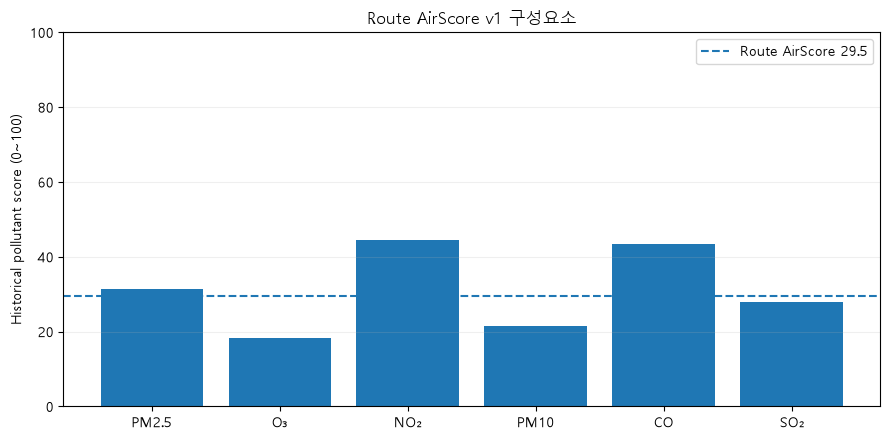

In [15]:
plt.figure(
    figsize=(9, 4.5)
)

plt.bar(
    component_table["label"],
    component_table[
        "route_pollutant_score"
    ]
)

plt.axhline(
    route_summary["RouteAirScore"],
    linestyle="--",
    label=(
        "Route AirScore "
        f"{route_summary['RouteAirScore']:.1f}"
    )
)

plt.ylim(
    0,
    100
)

plt.ylabel(
    "Historical pollutant score (0~100)"
)

plt.title(
    "Route AirScore v1 구성요소"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

# 15. Median vs P90 sensitivity

기본 추천에는 `median`을 사용한다.

보수적 조건을 보고 싶으면 같은 코스를 `p90`으로 다시 계산한다.

```text
median
→ 평소/전형적인 historical air context

p90
→ historical 고농도 상황을 가정한 보수적 context
```


In [16]:
median_summary, _ = get_route_airscore(
    route_segments=ROUTE_SEGMENTS,
    month=RUN_MONTH,
    start_hour=START_HOUR,
    start_minute=START_MINUTE,
    pace_min_per_km=PACE_MIN_PER_KM,
    statistic="median"
)


p90_summary, _ = get_route_airscore(
    route_segments=ROUTE_SEGMENTS,
    month=RUN_MONTH,
    start_hour=START_HOUR,
    start_minute=START_MINUTE,
    pace_min_per_km=PACE_MIN_PER_KM,
    statistic="p90"
)


sensitivity = pd.DataFrame([
    {
        "scenario": "median baseline",
        "AirScore": median_summary[
            "RouteAirScore"
        ]
    },
    {
        "scenario": "p90 high-pollution",
        "AirScore": p90_summary[
            "RouteAirScore"
        ]
    }
])


display(
    sensitivity
)

,scenario,AirScore
0,median baseline,29.5224
1,p90 high-pollution,8.3371


# 16. AirScore 해석

AirScore는 2019~2025 서울 historical distribution에 대한 상대점수다.

아래 구간은 프로젝트 UI에서 이해하기 쉽게 보여주기 위한 **설명용 heuristic label**이다.

| AirScore | 설명 |
|---:|---|
| 80~100 | historical 기준 매우 양호 |
| 60~80 | 비교적 양호 |
| 40~60 | 중간 수준 |
| 20~40 | 비교적 불리 |
| 0~20 | historical 기준 매우 불리 |

이 구간은 법적 대기질 등급이나 건강 안전 기준이 아니다.


In [17]:
def interpret_airscore(score):

    if pd.isna(score):
        return "계산 불가"

    if score >= 80:
        return "historical 기준 매우 양호"

    if score >= 60:
        return "비교적 양호"

    if score >= 40:
        return "중간 수준"

    if score >= 20:
        return "비교적 불리"

    return "historical 기준 매우 불리"


print(
    interpret_airscore(
        route_summary[
            "RouteAirScore"
        ]
    )
)

비교적 불리


# 17. 팀원이 실제로 사용할 함수

아래 함수 하나만 호출하면 된다.


In [18]:
def run_airscore(
    route_segments,
    month,
    start_hour,
    start_minute=0,
    pace_min_per_km=6.0,
    statistic="median",
    show_chunks=True
):
    summary, chunks = get_route_airscore(
        route_segments=route_segments,
        month=month,
        start_hour=start_hour,
        start_minute=start_minute,
        pace_min_per_km=pace_min_per_km,
        statistic=statistic
    )

    score = summary[
        "RouteAirScore"
    ]

    print(
        "=" * 70
    )

    print(
        f"Route AirScore: "
        f"{score:.2f} / 100"
    )

    print(
        "해석:",
        interpret_airscore(
            score
        )
    )

    print(
        f"거리: "
        f"{summary['total_distance_km']:.2f} km"
    )

    print(
        f"예상 러닝시간: "
        f"{summary['total_minutes']:.1f} 분"
    )

    print(
        "=" * 70
    )

    component_rows = []

    for pollutant, weight in AIR_WEIGHTS.items():

        component_rows.append({
            "pollutant":
                POLLUTANT_LABELS[
                    pollutant
                ],

            "weight":
                weight,

            "pollutant_score":
                summary[
                    f"{pollutant}_route_score"
                ],

            "weighted_contribution":
                summary[
                    f"{pollutant}_route_score"
                ]
                *
                weight,

            "relative_to_seoul":
                summary.get(
                    f"{pollutant}_route_relative",
                    np.nan
                )
        })


    components = pd.DataFrame(
        component_rows
    )

    display(
        components
    )


    if show_chunks:

        display(
            chunks[
                [
                    "segment_index",
                    "district",
                    "start_clock",
                    "end_clock",
                    "hour",
                    "distance_km",
                    "minutes",
                    "time_weight",
                    "slot_AirScore"
                ]
            ]
        )


    return {
        "summary": summary,
        "components": components,
        "chunks": chunks
    }

# 18. 팀원 사용 방법

## 1. 코스 입력

```python
ROUTE_SEGMENTS = [
    {
        "district": "강남구",
        "distance_km": 4.0
    },
    {
        "district": "송파구",
        "distance_km": 6.0
    }
]
```

---

## 2. 월 / 출발시간 / 페이스 입력

```python
RUN_MONTH = 3

START_HOUR = 16

START_MINUTE = 0

PACE_MIN_PER_KM = 6.0
```

---

## 3. 실행

```python
result = run_airscore(
    route_segments=ROUTE_SEGMENTS,
    month=RUN_MONTH,
    start_hour=START_HOUR,
    start_minute=START_MINUTE,
    pace_min_per_km=PACE_MIN_PER_KM,
    statistic="median"
)
```

---

## 4. 결과

```text
Route AirScore: 0~100

높을수록
→ 2019~2025 서울 historical distribution에서
   상대적으로 낮은 대기오염 조건

낮을수록
→ historical distribution에서
   상대적으로 높은 대기오염 조건
```

각 오염물질 component score와 구간별 점수도 함께 출력된다.

---

## 5. 보수적 시나리오

평소 수준이 아니라 historical 고농도 상황을 보고 싶다면:

```python
result = run_airscore(
    route_segments=ROUTE_SEGMENTS,
    month=RUN_MONTH,
    start_hour=START_HOUR,
    start_minute=START_MINUTE,
    pace_min_per_km=PACE_MIN_PER_KM,
    statistic="p90"
)
```

---

## 중요

이 AirScore는:

```text
2019~2025 historical air data
+
district × month × hour climatology
+
empirical percentile scaling
+
fixed pollutant weights
```

로 계산한 **러닝 코스 비교용 상대점수**다.

실시간 대기질 예보나 법적 AQI를 대체하지 않는다.


# 19. 최종 실행 예시

In [19]:
result = run_airscore(
    route_segments=[
        {
            "district": "강남구",
            "distance_km": 4.0
        },
        {
            "district": "송파구",
            "distance_km": 6.0
        }
    ],
    month=3,
    start_hour=16,
    start_minute=0,
    pace_min_per_km=6.0,
    statistic="median"
)

Route AirScore: 29.52 / 100
해석: 비교적 불리
거리: 10.00 km
예상 러닝시간: 60.0 분


,pollutant,weight,pollutant_score,weighted_contribution,relative_to_seoul
0,PM2.5,0.4000,31.4502,12.5801,-0.5510
1,O₃,0.2500,18.1866,4.5466,-0.0004
2,NO₂,0.1500,44.4658,6.6699,0.0026
3,PM10,0.1000,21.5793,2.1579,-0.2583
4,CO,0.0500,43.5216,2.1761,0.0037
5,SO₂,0.0500,27.8355,1.3918,0.0000


,segment_index,district,start_clock,end_clock,hour,distance_km,minutes,time_weight,slot_AirScore
0,1,강남구,16:00,16:24,16,4.0000,24.0000,0.4000,30.5737
1,2,송파구,16:24,17:00,16,6.0000,36.0000,0.6000,28.8215


# 20. 결과 CSV 저장 예시

실제 추천 파이프라인에서는 `RouteAirScore`와 pollutant component를 route feature table에 붙이면 된다.


In [20]:
example_summary_path = (
    OUTPUT_DIR
    / "example_route_airscore_summary.csv"
)

example_chunks_path = (
    OUTPUT_DIR
    / "example_route_airscore_chunks.csv"
)


pd.DataFrame(
    [result["summary"]]
).to_csv(
    example_summary_path,
    index=False,
    encoding="utf-8-sig"
)


result["chunks"].to_csv(
    example_chunks_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "저장 완료:"
)

print(
    example_summary_path
)

print(
    example_chunks_path
)

저장 완료:
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\airscore_v1\example_route_airscore_summary.csv
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\airscore_v1\example_route_airscore_chunks.csv


# 21. AirScore v1 최종 구조

대기질 파트는 이제 다음 구조로 고정한다.

```text
사용자 입력
month
start time
pace
route segment별 district + distance

        ↓

district × month × hour
historical climatology 조회

        ↓

각 pollutant concentration을
2019~2025 서울 hourly percentile로 scaling

        ↓

PollutantScore = 100 - percentile

        ↓

PM2.5   40%
O3      25%
NO2     15%
PM10    10%
CO       5%
SO2      5%

        ↓

시간 chunk별 AirScore

        ↓

실제 러닝 소요시간 가중평균

        ↓

Route AirScore (0~100)
```

## 최종 원칙

### 1. 점수는 구별 고정점수가 아니다

```text
강남구 = 70
송파구 = 80
```

형태가 아니다.

대신:

```text
강남구 × 3월 × 16시
송파구 × 3월 × 16시
```

처럼 러닝 조건에 따라 달라진다.

### 2. 여러 구를 지나면 실제 노출시간으로 합친다

코스 전체가 하나의 Route AirScore를 가진다.

### 3. relative feature는 설명용으로 보존한다

서울 평균 대비 상대편차는 최종 weighted AirScore에 중복 반영하지 않는다.

### 4. 기본 추천은 median

```text
median
→ 평소 historical condition
```

을 기본으로 한다.

`p90`은 보수적 시나리오 확인용이다.

---

이 `Route AirScore`가 이후:

```text
Route feature
+
Weather feature
+
AirScore
```

를 결합하는 최종 러닝 추천 모델의 대기질 입력값이 된다.
